# Fase 2: telemetría — ¿dónde gana tiempo un piloto?
## cargar la telemetría

In [2]:
import os
from pathlib import Path

# Subir de carpeta en carpeta hasta encontrar la raíz del proyecto
# (la que contiene requirements.txt) y trabajar desde ahí
raiz = Path.cwd()
for _ in range(5):
    if (raiz / 'requirements.txt').exists():
        break
    raiz = raiz.parent
os.chdir(raiz)
print('Trabajando en:', raiz)

Trabajando en: /Users/alvaroruiz/Desktop/proyecto f1/f1-strategy-analytics


In [3]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('cache')

# 'Q' = clasificación
q = fastf1.get_session(2024, 'Monza', 'Q')
q.load()

# La vuelta más rápida de cada piloto en toda la clasificación
vuelta_nor = q.laps.pick_drivers('NOR').pick_fastest()
vuelta_lec = q.laps.pick_drivers('LEC').pick_fastest()

print('Norris: ', vuelta_nor['LapTime'])
print('Leclerc:', vuelta_lec['LapTime'])
diferencia = (vuelta_lec['LapTime'] - vuelta_nor['LapTime']).total_seconds()
print(f'Diferencia: {diferencia:.3f} s')

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

Norris:  0 days 00:01:19.327000
Leclerc: 0 days 00:01:19.461000
Diferencia: 0.134 s


In [4]:
# get_car_data(): datos del coche ~4 veces por segundo
# add_distance(): añade los metros recorridos desde el inicio de la vuelta
tel_nor = vuelta_nor.get_car_data().add_distance()
tel_lec = vuelta_lec.get_car_data().add_distance()

print('Filas Norris: ', len(tel_nor))
print('Filas Leclerc:', len(tel_lec))
tel_nor.head(10)

Filas Norris:  306
Filas Leclerc: 314


,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2024-08-31 15:02:50.688,11334.0,321.0,8,99.0,False,14,car,0 days 00:00:00.172000,0 days 01:13:52.919000,15.336667
1,2024-08-31 15:02:50.888,11378.0,322.0,8,99.0,False,14,car,0 days 00:00:00.372000,0 days 01:13:53.119000,33.225556
2,2024-08-31 15:02:51.208,11457.0,325.0,8,99.0,False,14,car,0 days 00:00:00.692000,0 days 01:13:53.439000,62.114444
3,2024-08-31 15:02:51.608,11542.0,328.0,8,99.0,False,14,car,0 days 00:00:01.092000,0 days 01:13:53.839000,98.558889
4,2024-08-31 15:02:51.968,11615.0,330.0,8,99.0,False,14,car,0 days 00:00:01.452000,0 days 01:13:54.199000,131.558889
5,2024-08-31 15:02:52.328,11681.0,332.0,8,99.0,False,14,car,0 days 00:00:01.812000,0 days 01:13:54.559000,164.758889
6,2024-08-31 15:02:52.528,11738.0,333.0,8,99.0,False,14,car,0 days 00:00:02.012000,0 days 01:13:54.759000,183.258889
7,2024-08-31 15:02:52.728,11763.0,334.0,8,99.0,False,14,car,0 days 00:00:02.212000,0 days 01:13:54.959000,201.814444
8,2024-08-31 15:02:52.889,11782.0,334.0,8,99.0,False,14,car,0 days 00:00:02.373000,0 days 01:13:55.120000,216.751667
9,2024-08-31 15:02:53.209,11824.0,336.0,8,99.0,False,14,car,0 days 00:00:02.693000,0 days 01:13:55.440000,246.618333


In [5]:
for nombre, tel in [('Norris', tel_nor), ('Leclerc', tel_lec)]:
    print(f"{nombre}: velocidad máx. {tel['Speed'].max()} km/h · "
          f"% de la vuelta a fondo: {(tel['Throttle'] >= 99).mean() * 100:.1f} % · "
          f"% frenando: {tel['Brake'].mean() * 100:.1f} %")

Norris: velocidad máx. 347.0 km/h · % de la vuelta a fondo: 76.1 % · % frenando: 11.4 %
Leclerc: velocidad máx. 351.0 km/h · % de la vuelta a fondo: 75.5 % · % frenando: 13.7 %


##  comparar la vuelta

In [6]:
import matplotlib.pyplot as plt
import fastf1.plotting

# Color oficial de cada piloto en esta sesión
colores = {p: fastf1.plotting.get_driver_color(p, session=q) for p in ['NOR', 'LEC']}

# Posición de las curvas (viene de la API de MultiViewer, puede fallar sin conexión)
try:
    curvas = q.get_circuit_info().corners
    print(f'{len(curvas)} curvas')
except Exception as e:
    curvas = None
    print('No se pudo cargar la info del circuito:', e)

req            INFO 	Using cached data for driver_info


11 curvas


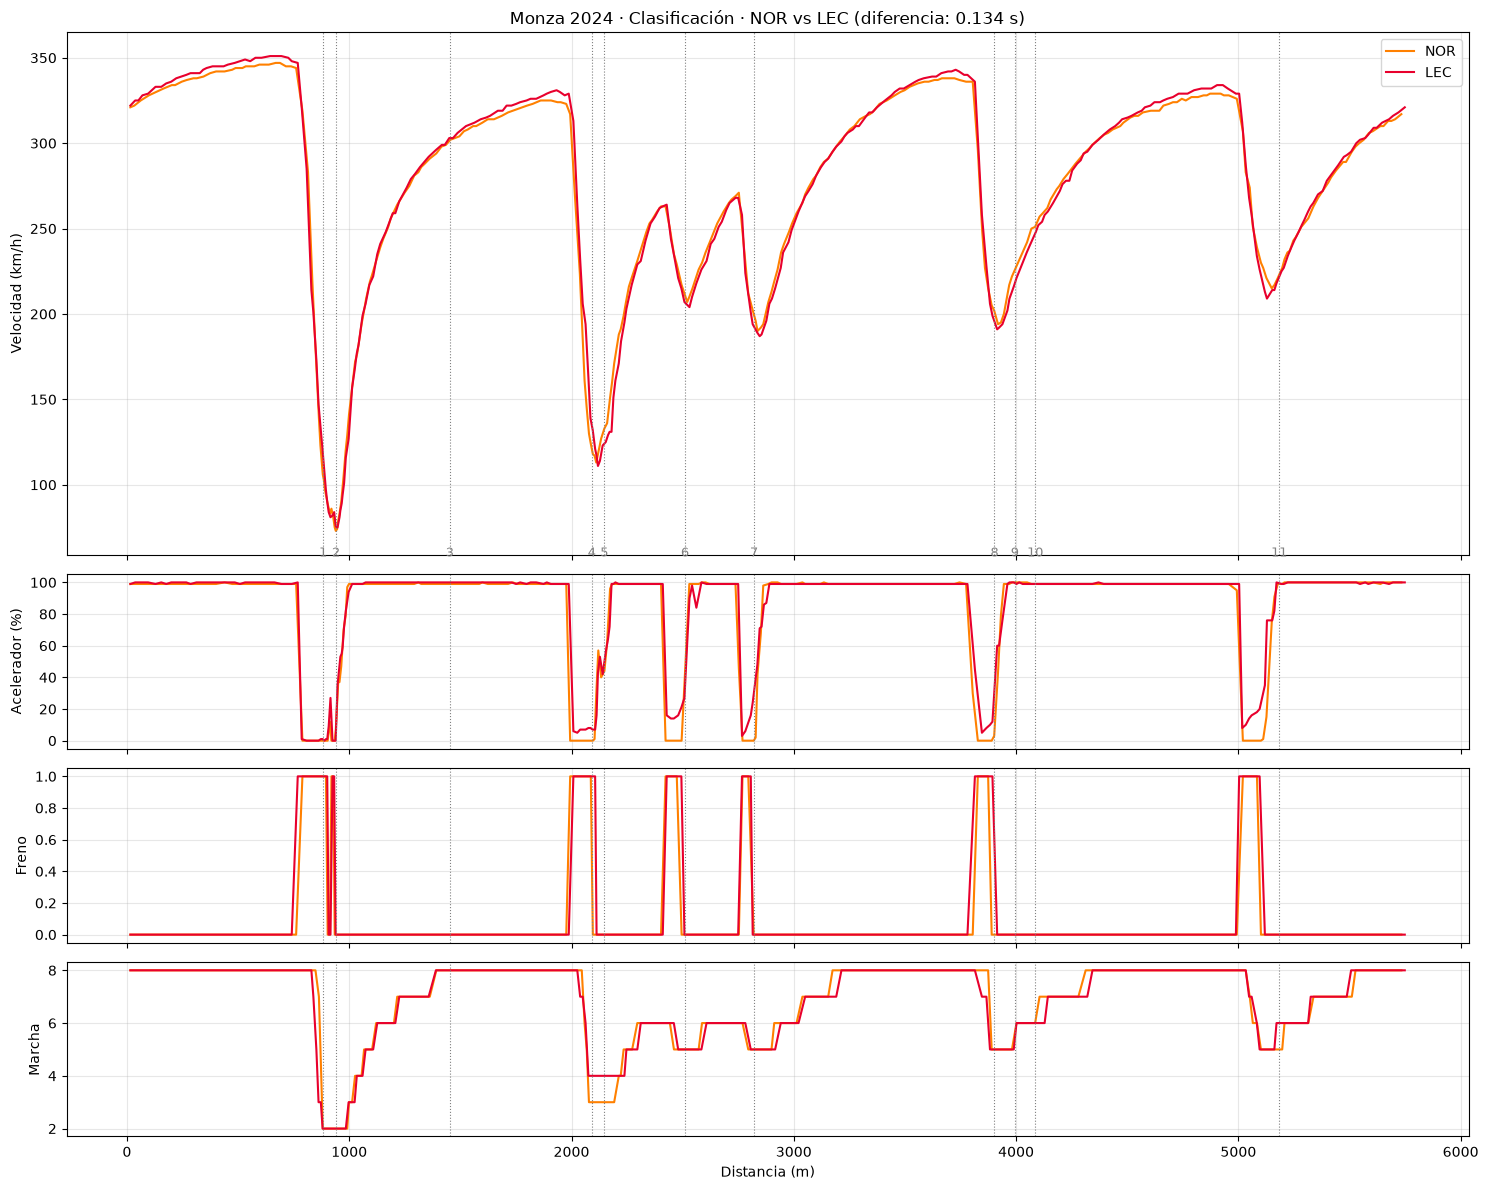

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1, 1]})

for piloto, tel in [('NOR', tel_nor), ('LEC', tel_lec)]:
    c = colores[piloto]
    axes[0].plot(tel['Distance'], tel['Speed'], color=c, label=piloto)
    axes[1].plot(tel['Distance'], tel['Throttle'], color=c)
    axes[2].plot(tel['Distance'], tel['Brake'].astype(int), color=c)
    axes[3].plot(tel['Distance'], tel['nGear'], color=c)

# Líneas verticales y número en cada curva
if curvas is not None:
    for _, curva in curvas.iterrows():
        for ax in axes:
            ax.axvline(curva['Distance'], color='gray', linestyle=':', linewidth=0.8)
        etiqueta = f"{curva['Number']}{curva['Letter'] or ''}"
        axes[0].text(curva['Distance'], tel_nor['Speed'].min() - 15, etiqueta,
                     ha='center', fontsize=9, color='gray')

axes[0].set_ylabel('Velocidad (km/h)')
axes[1].set_ylabel('Acelerador (%)')
axes[2].set_ylabel('Freno')
axes[3].set_ylabel('Marcha')
axes[3].set_xlabel('Distancia (m)')
axes[0].legend()
axes[0].set_title(f'Monza 2024 · Clasificación · NOR vs LEC (diferencia: {diferencia:.3f} s)')
for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/telemetria_monza_q_nor_lec.png', dpi=150)
plt.show()

# Delta del tiempo

In [9]:
import numpy as np

def tiempo_en_malla(tel, malla):
    """Tiempo (s) que tarda el piloto en llegar a cada metro de la malla."""
    return np.interp(malla, tel['Distance'], tel['Time'].dt.total_seconds())

# Malla común: un punto cada 5 metros, hasta donde llegan los datos de ambos
fin = min(tel_nor['Distance'].max(), tel_lec['Distance'].max())
malla = np.arange(0, fin, 5)

t_nor = tiempo_en_malla(tel_nor, malla)
t_lec = tiempo_en_malla(tel_lec, malla)

# Positivo = Leclerc va por detrás de Norris en ese punto
delta = t_lec - t_nor
print(f'Delta al final de la vuelta: {delta[-1]:.3f} s (oficial: {diferencia:.3f} s)')

Delta al final de la vuelta: 0.068 s (oficial: 0.134 s)


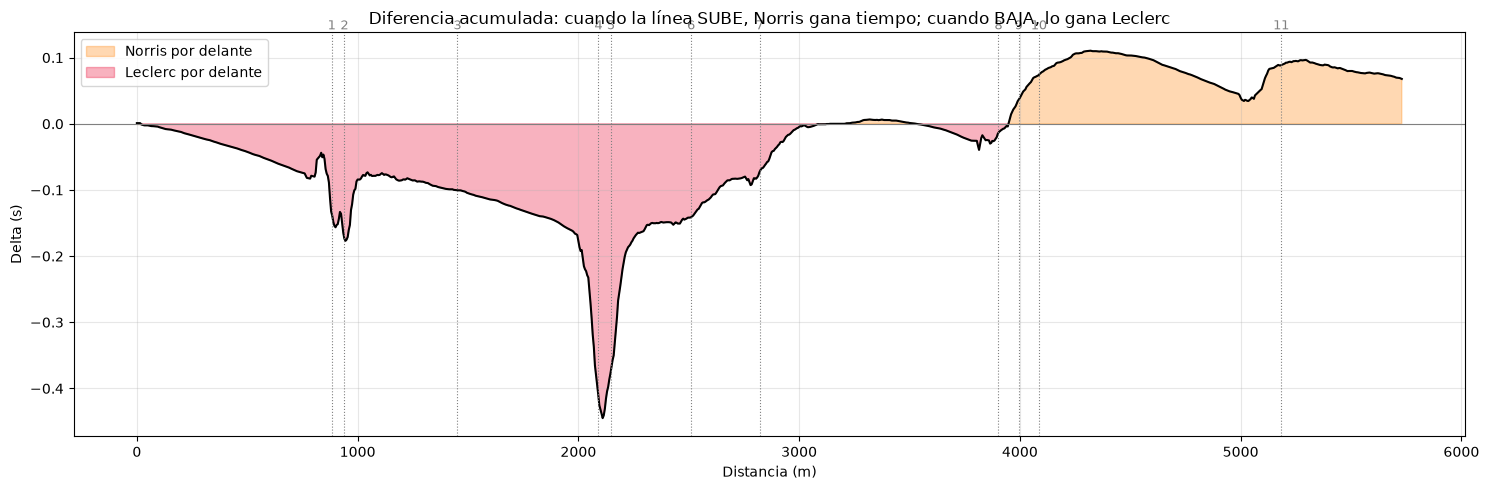

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(malla, delta, color='black', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8)

# Rellenamos según quién va por delante en cada punto
ax.fill_between(malla, delta, 0, where=delta > 0, color=colores['NOR'], alpha=0.3,
                label='Norris por delante')
ax.fill_between(malla, delta, 0, where=delta < 0, color=colores['LEC'], alpha=0.3,
                label='Leclerc por delante')

if curvas is not None:
    for _, curva in curvas.iterrows():
        ax.axvline(curva['Distance'], color='gray', linestyle=':', linewidth=0.8)
        ax.text(curva['Distance'], ax.get_ylim()[1], f"{curva['Number']}{curva['Letter'] or ''}",
                ha='center', va='bottom', fontsize=9, color='gray')

ax.set_xlabel('Distancia (m)')
ax.set_ylabel('Delta (s)')
ax.set_title('Diferencia acumulada: cuando la línea SUBE, Norris gana tiempo; cuando BAJA, lo gana Leclerc')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/delta_monza_q_nor_lec.png', dpi=150)
plt.show()

In [11]:
# Dividimos la vuelta en tramos entre curvas y medimos cuánto cambia el delta en cada uno
if curvas is not None:
    limites = [0] + curvas['Distance'].tolist() + [fin]
    nombres = ['Salida → C1'] + [
        f"C{a['Number']}{a['Letter'] or ''} → " + (f"C{b['Number']}{b['Letter'] or ''}" if b is not None else 'Meta')
        for (_, a), b in zip(curvas.iterrows(), [r for _, r in curvas.iloc[1:].iterrows()] + [None])
    ]
else:
    limites = list(np.linspace(0, fin, 11))           # sin curvas: 10 tramos iguales
    nombres = [f'Tramo {i + 1}' for i in range(10)]

delta_en = np.interp(limites, malla, delta)
tramos = pd.DataFrame({
    'tramo': nombres,
    'desde_m': np.round(limites[:-1]),
    'hasta_m': np.round(limites[1:]),
    'gana_NOR_s': np.round(np.diff(delta_en), 3),     # positivo: Norris gana; negativo: Leclerc
})
tramos.sort_values('gana_NOR_s', ascending=False)

,tramo,desde_m,hasta_m,gana_NOR_s
5,C5 → C6,2147.0,2510.0,0.232
2,C2 → C3,940.0,1452.0,0.073
6,C6 → C7,2510.0,2821.0,0.069
7,C7 → C8,2821.0,3903.0,0.059
8,C8 → C9,3903.0,3994.0,0.050
4,C4 → C5,2091.0,2147.0,0.039
9,C9 → C10,3994.0,4086.0,0.038
10,C10 → C11,4086.0,5183.0,0.015
11,C11 → Meta,5183.0,5733.0,-0.021
1,C1 → C2,882.0,940.0,-0.038


In [12]:
pd.DataFrame({
    piloto: [v[f'Sector{s}Time'].total_seconds() for s in (1, 2, 3)]
    for piloto, v in [('NOR', vuelta_nor), ('LEC', vuelta_lec)]
}, index=['Sector 1', 'Sector 2', 'Sector 3']).assign(dif=lambda d: (d['LEC'] - d['NOR']).round(3))

,NOR,LEC,dif
Sector 1,26.492,26.373,-0.119
Sector 2,26.579,26.732,0.153
Sector 3,26.256,26.356,0.100


## función reutilizable y mapa

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']


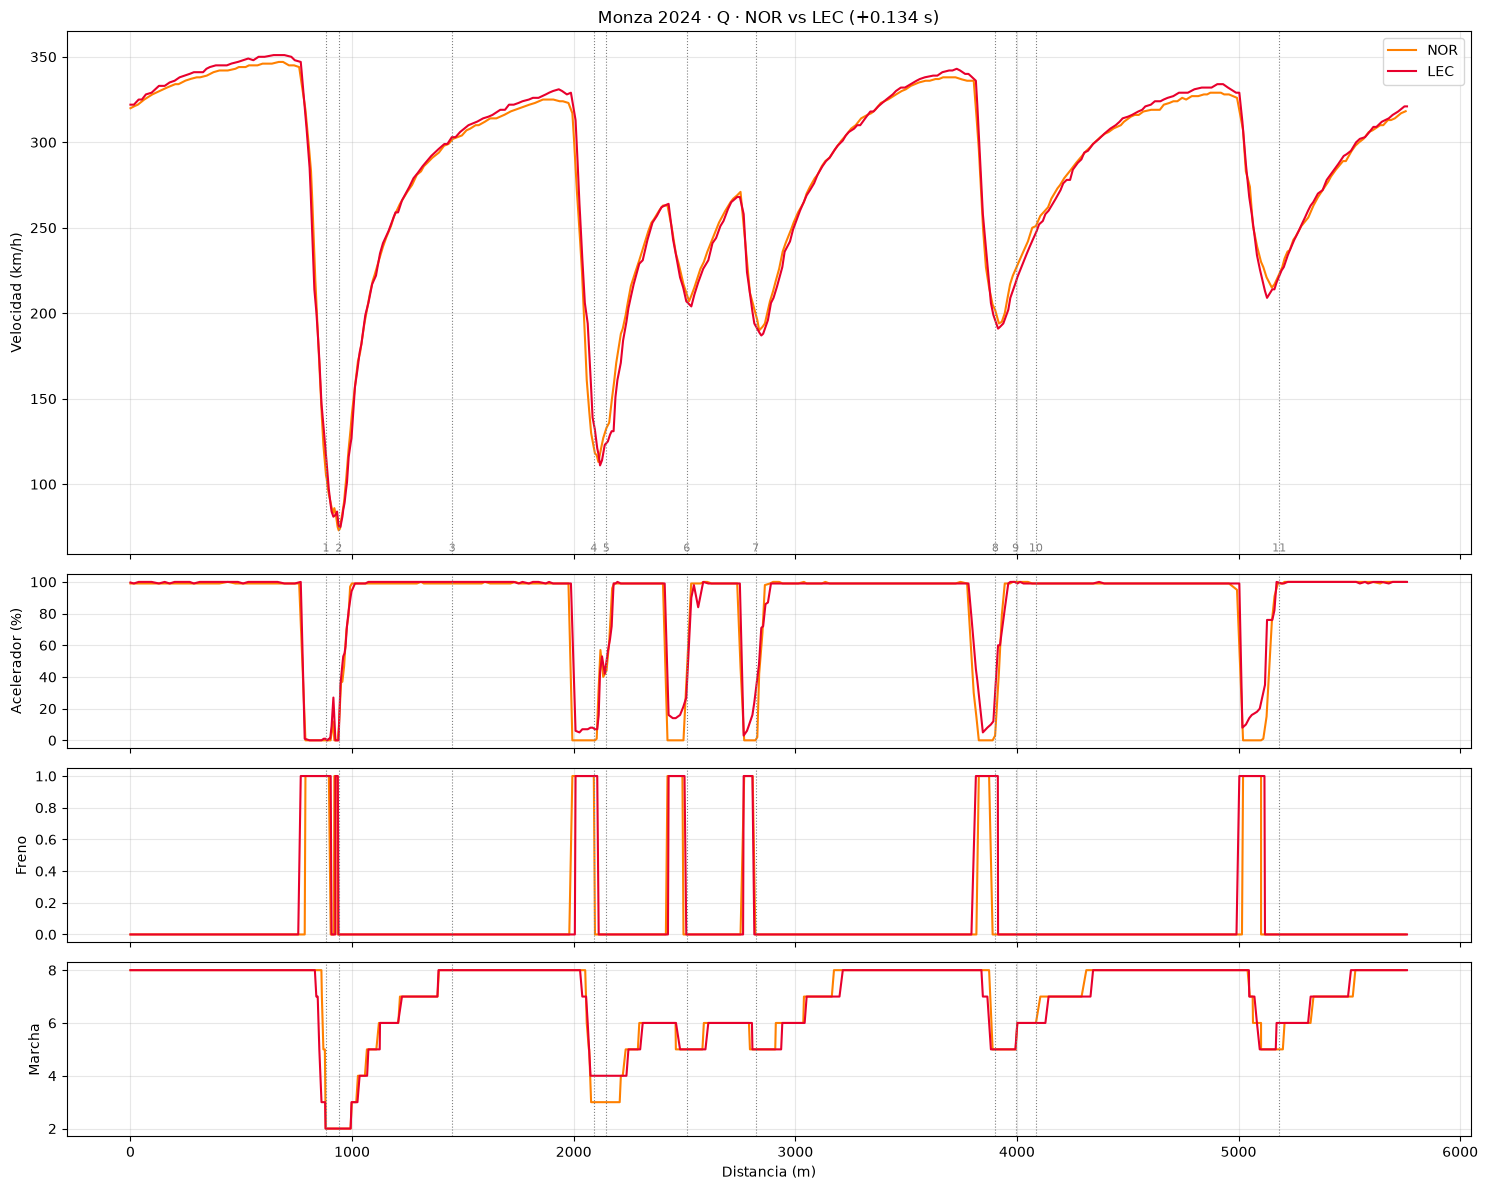

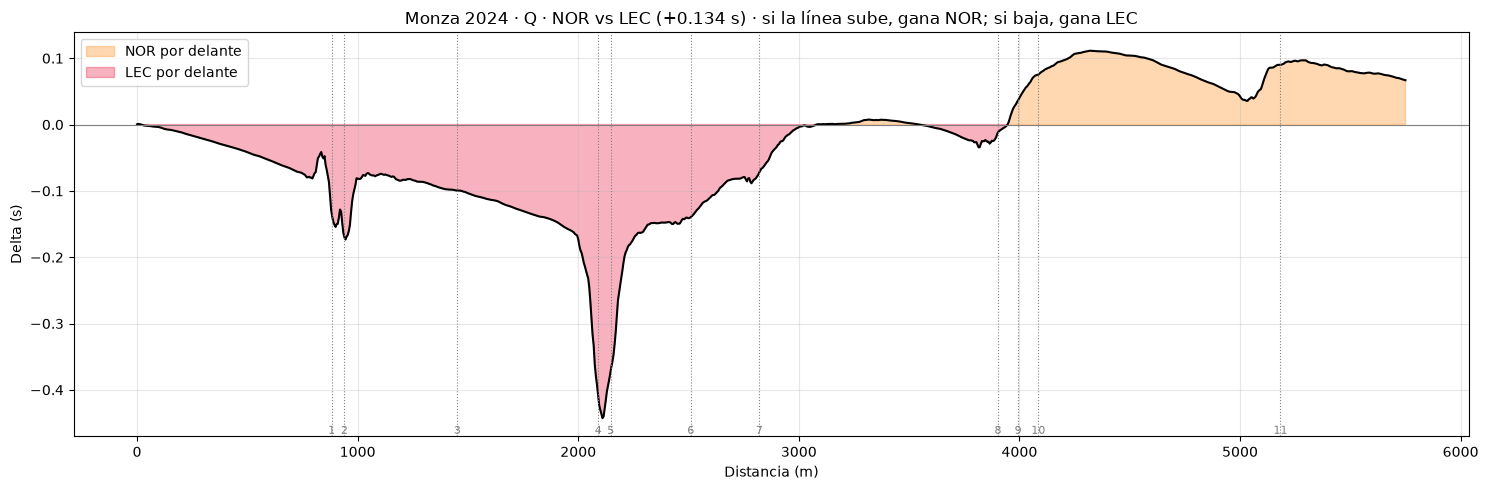

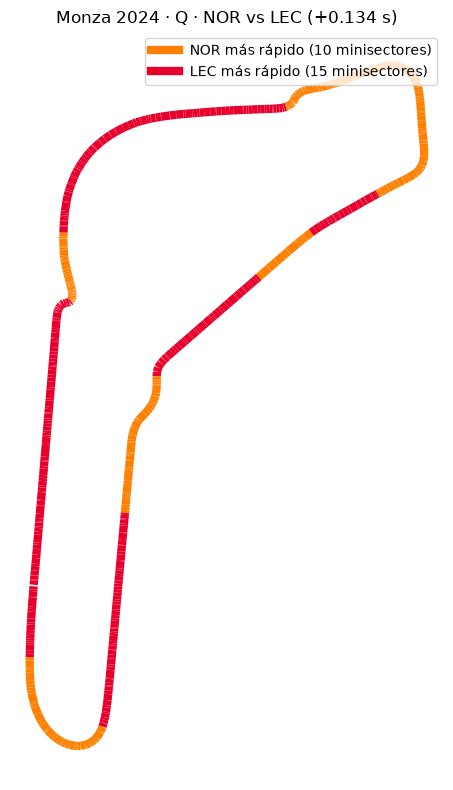

,tramo,desde_m,hasta_m,gana_NOR_s
5,C5 → C6,2147.0,2510.0,0.231
2,C2 → C3,940.0,1452.0,0.070
6,C6 → C7,2510.0,2821.0,0.067
7,C7 → C8,2821.0,3903.0,0.060
8,C8 → C9,3903.0,3994.0,0.049
4,C4 → C5,2091.0,2147.0,0.039
9,C9 → C10,3994.0,4086.0,0.039
10,C10 → C11,4086.0,5183.0,0.015
11,C11 → Meta,5183.0,5750.0,-0.023
1,C1 → C2,882.0,940.0,-0.036


In [13]:
import importlib
import src.telemetry as telemetry
importlib.reload(telemetry)    # recarga el archivo si lo cambias

resultado = telemetry.comparar_pilotos(2024, 'Monza', 'NOR', 'LEC')
resultado['tramos'].sort_values('gana_NOR_s', ascending=False)

## 3 circuitos

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



========== Monza 2024: NOR vs LEC ==========


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']


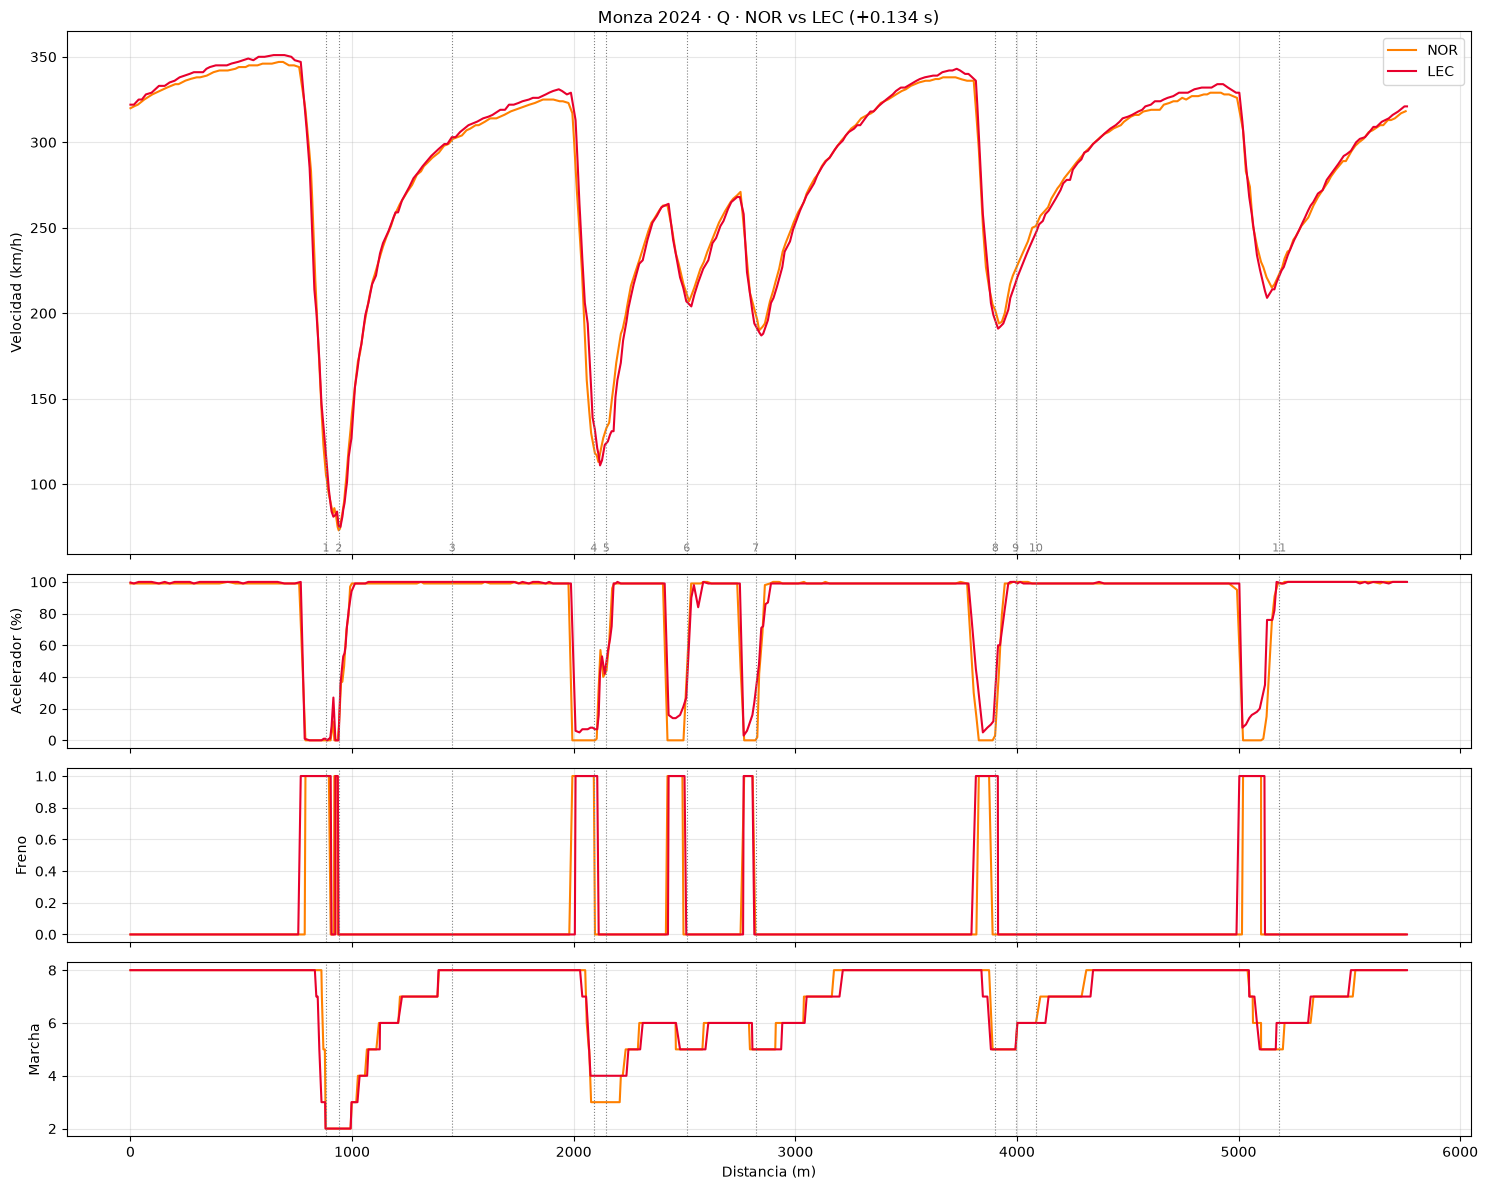

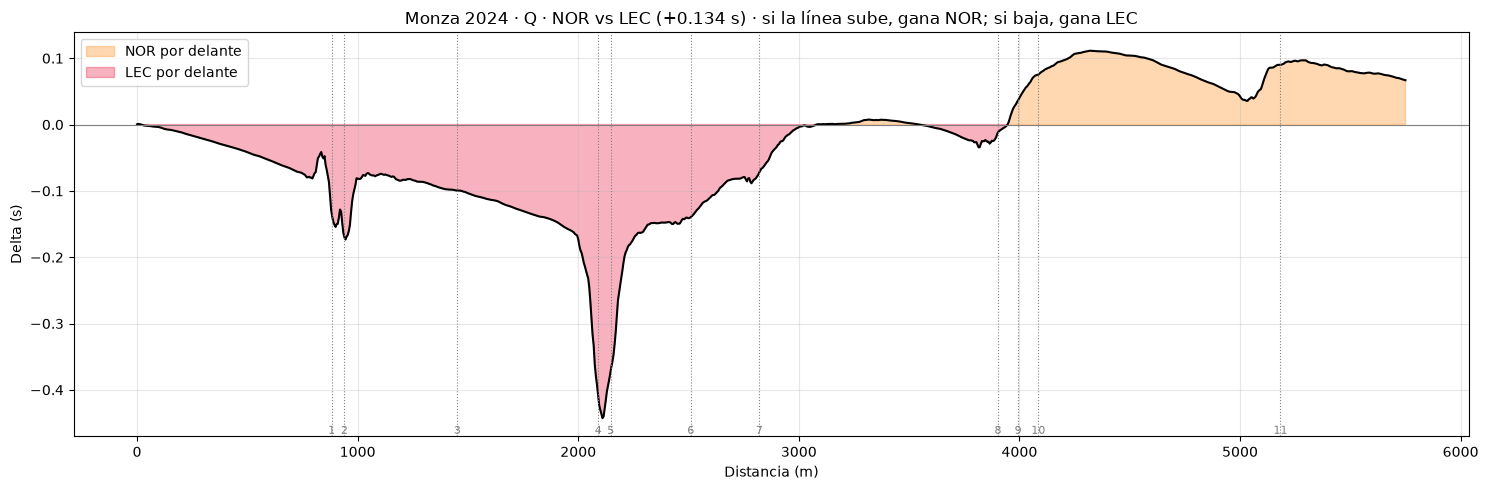

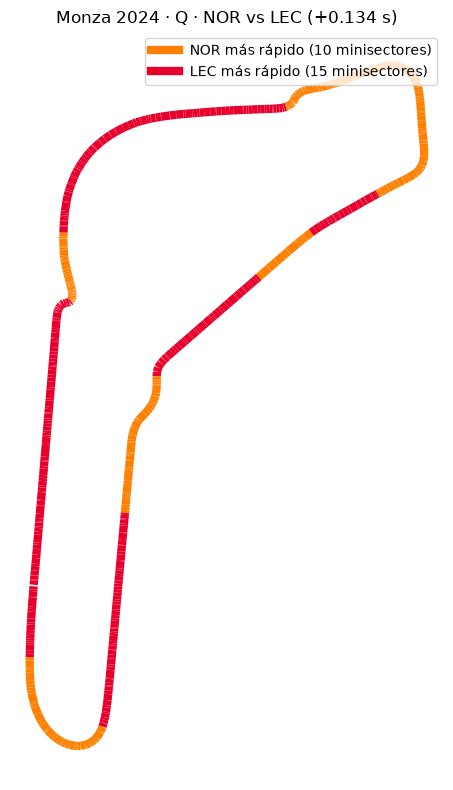

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...



========== Monaco 2024: LEC vs PIA ==========


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to cache!
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api

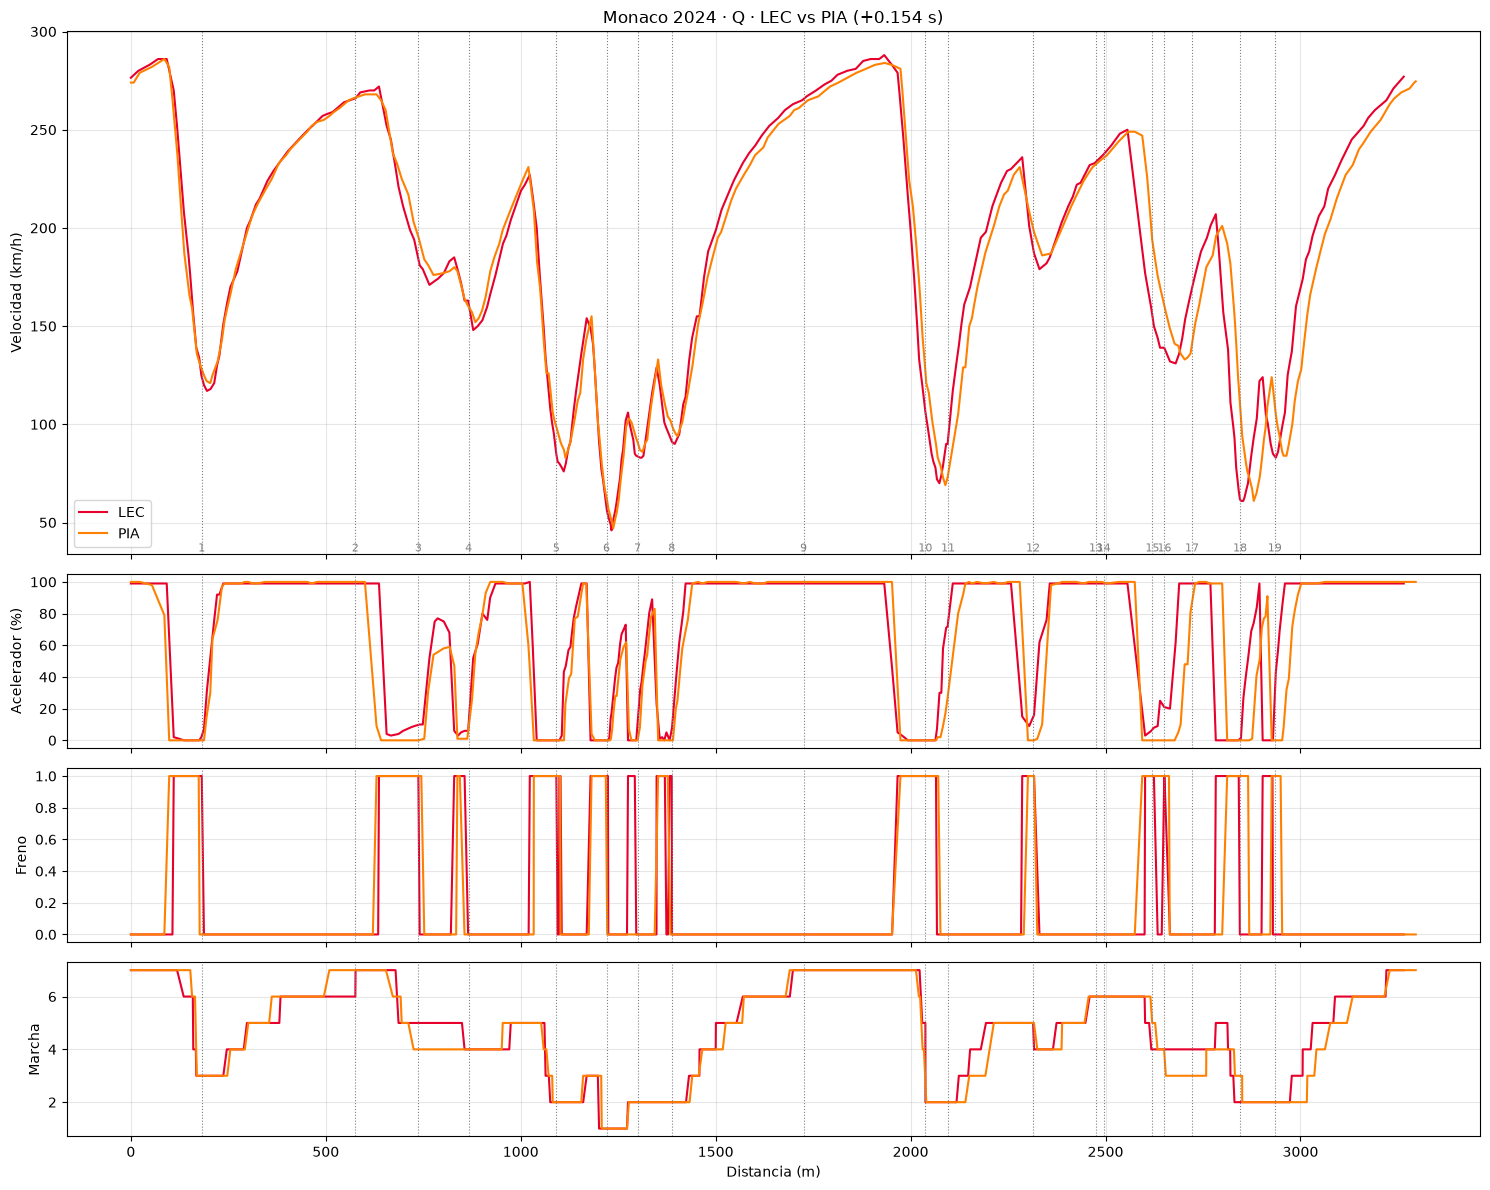

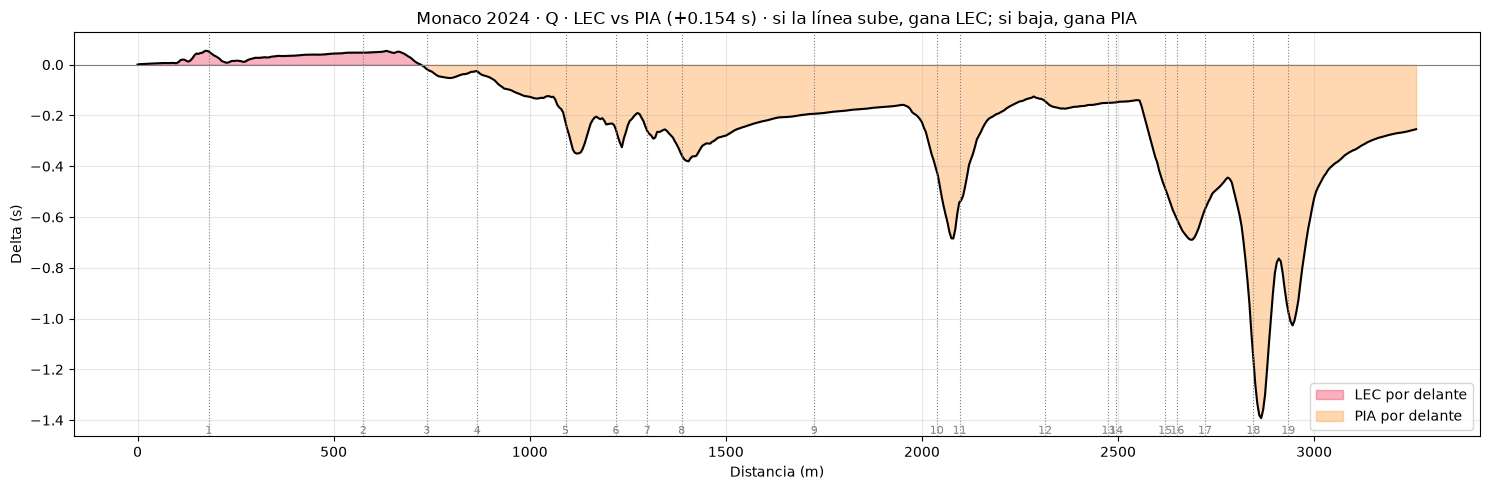

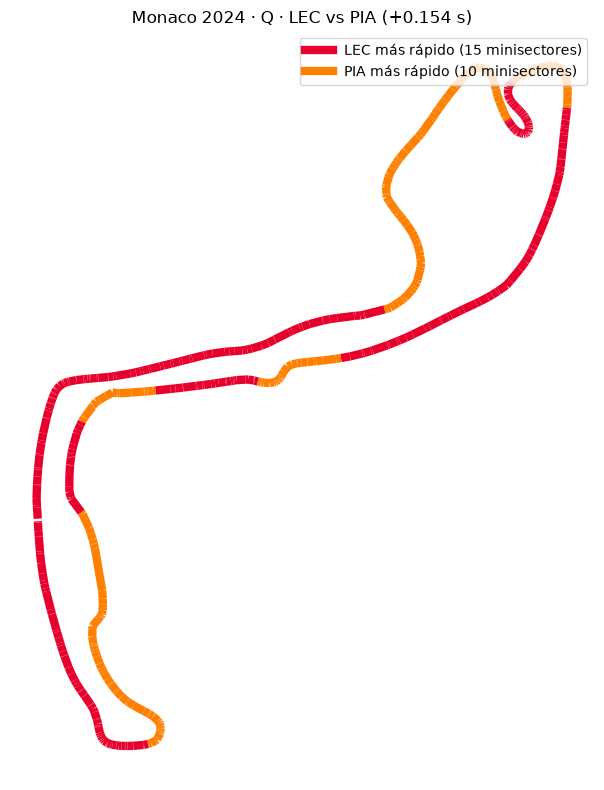

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...



========== Suzuka 2024: VER vs NOR ==========


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to cache!
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api

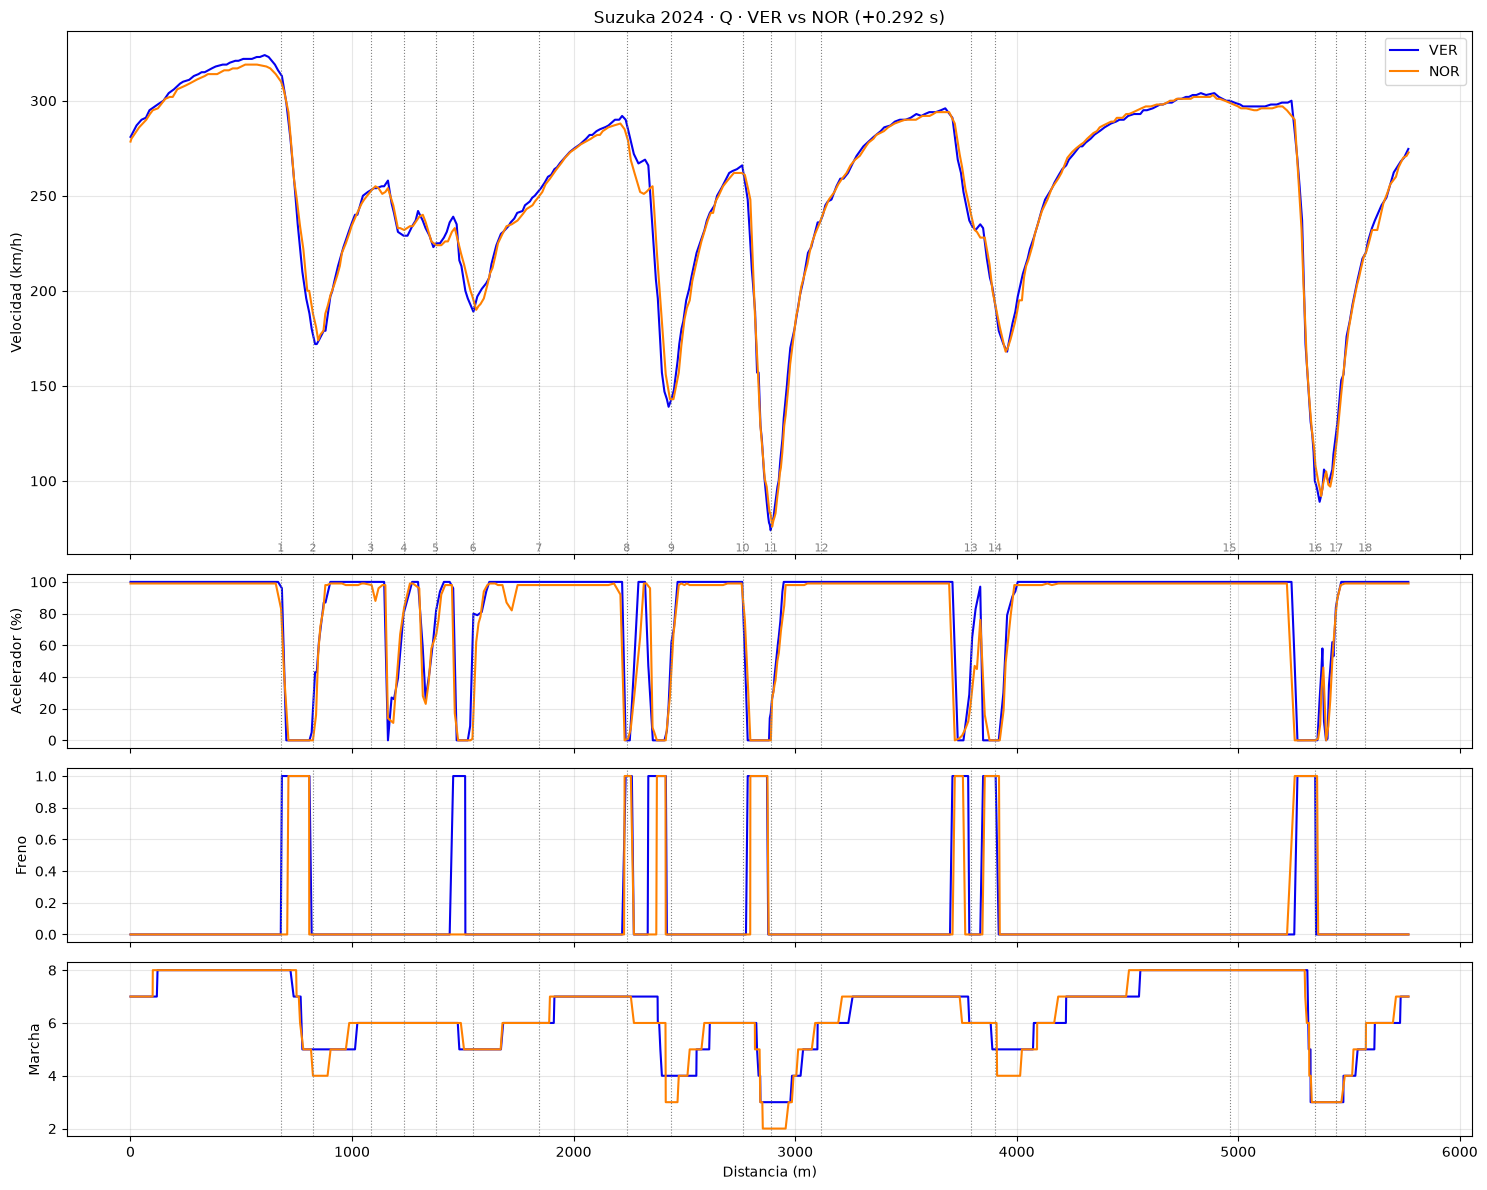

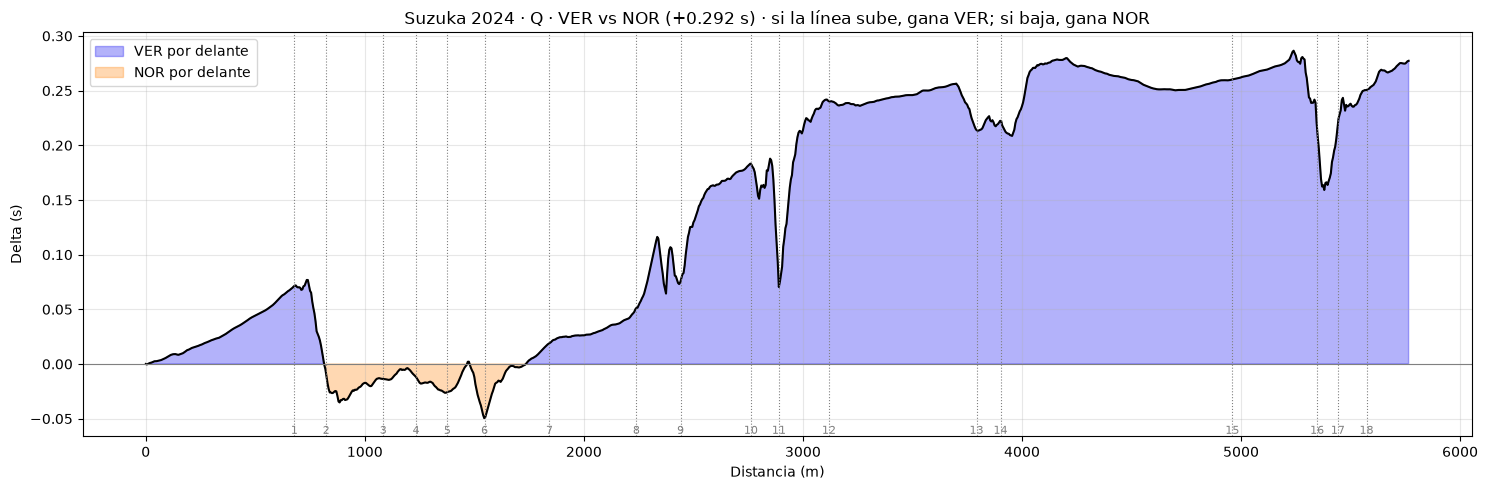

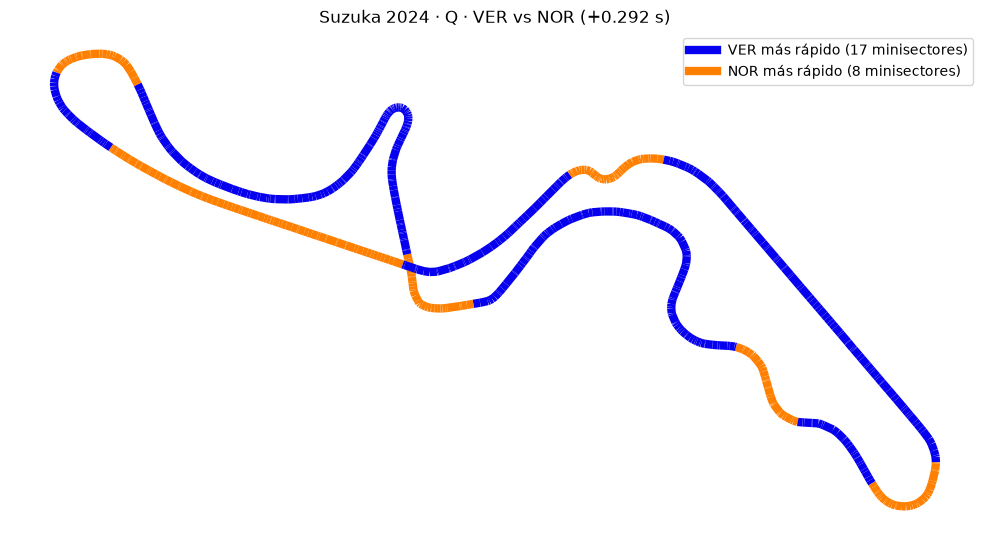

In [14]:
comparaciones = [
    (2024, 'Monza', 'NOR', 'LEC'),
    (2024, 'Monaco', 'LEC', 'PIA'),
    (2024, 'Suzuka', 'VER', 'NOR'),
]

resultados = {}
for year, gp, p1, p2 in comparaciones:
    print(f'\n========== {gp} {year}: {p1} vs {p2} ==========')
    resultados[gp] = telemetry.comparar_pilotos(year, gp, p1, p2)

In [15]:
import os

filas = []
for (year, gp, p1, p2) in comparaciones:
    t = resultados[gp]['tramos'].rename(columns={f'gana_{p1}_s': 'gana_p1_s'})
    t.insert(0, 'gp', gp)
    t.insert(1, 'piloto_1', p1)
    t.insert(2, 'piloto_2', p2)
    filas.append(t)

resumen_tramos = pd.concat(filas, ignore_index=True)
os.makedirs('data/processed', exist_ok=True)
resumen_tramos.to_csv('data/processed/telemetria_tramos.csv', index=False)

# Diferencia total y tramo decisivo de cada comparación
(resumen_tramos
 .loc[resumen_tramos.groupby('gp')['gana_p1_s'].apply(lambda s: s.abs().idxmax())]
 .assign(diferencia_total_s=[resultados[gp]['diferencia'] for gp in resumen_tramos.loc[
     resumen_tramos.groupby('gp')['gana_p1_s'].apply(lambda s: s.abs().idxmax()), 'gp']])
 [['gp', 'piloto_1', 'piloto_2', 'diferencia_total_s', 'tramo', 'gana_p1_s']])

,gp,piloto_1,piloto_2,diferencia_total_s,tramo,gana_p1_s
31,Monaco,LEC,PIA,0.154,C19 → Meta,0.719
3,Monza,NOR,LEC,0.134,C3 → C4,-0.311
43,Suzuka,VER,NOR,0.292,C11 → C12,0.169


### Conclusiones de la Fase 2

**Monza (NOR vs LEC):**
- ✏️ Dónde ganó Norris la pole:
- ✏️ Qué hizo mejor Leclerc:

**Mónaco (LEC vs PIA):**
- ✏️ Dónde se decidió la diferencia:

**Suzuka (VER vs NOR):**
- ✏️ Dónde se decidió la diferencia:

**Conclusión general:**
- ✏️ ¿Se gana el tiempo en el mismo tipo de zona en los tres circuitos? ¿En rectas (motor y aerodinámica de baja carga), en frenadas (piloto) o en curvas rápidas (carga aerodinámica)?